# Spotify Exploratory Data Analysis (EDA)

## EDA for Baseline Model

### 1. Setup & Data Loading 

#### 1.1 Path Configuration 

If you followed the README correctly, the path configuration should be correct and you should have the following datasets required in `/data/cleaned/` or `/data/processed/` (_local_) **OR** `/kaggle/working/` (_kaggle_).

In [4]:
import os

# Configure data paths
SPOTIFY_VIRAL = "spotify_tracks_viral.parquet"
SPOTIFY_DROPPED = "spotify_tracks_dropped.parquet"
SPOTIFY_BASELINE = "spotify_tracks_baseline.parquet"

# Detect is running on Kaggle environment
IS_KAGGLE = os.path.exists('/kaggle/working/')

# Set input and output paths
if IS_KAGGLE:
    DATA_PATH = '/kaggle/working/'
    OUTPUT_PATH = '/kaggle/working/'
else:
    DATA_PATH = '../data/processed/'

#### 1.2 Import Packages

In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import argparse

from __future__ import annotations

### 2. EDA on Spotify Tracks with Viral Target

#### 2.1 Data Loading 

In [6]:
df = pd.read_parquet(os.path.join(DATA_PATH, SPOTIFY_VIRAL))

#### 2.2 Data Inspection

In [7]:
shape = df.shape
print(f"Shape of the dataset: {shape}")

Shape of the dataset: (113999, 22)


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113999 entries, 0 to 113998
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        113999 non-null  int64  
 1   track_id          113999 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        113999 non-null  int64  
 6   duration_ms       113999 non-null  int64  
 7   explicit          113999 non-null  bool   
 8   danceability      113999 non-null  float64
 9   energy            113999 non-null  float64
 10  key               113999 non-null  int64  
 11  loudness          113999 non-null  float64
 12  mode              113999 non-null  int64  
 13  speechiness       113999 non-null  float64
 14  acousticness      113999 non-null  float64
 15  instrumentalness  113999 non-null  float64
 16  liveness          11

#### 2.3 Artist with Most Number of Tracks

In [9]:
df_artist = df.groupby(['artists']).size().rename("count").to_frame()
df_artist.sort_values(by="count", ascending=False)

,count
artists,
the beatles,279
george jones,271
stevie wonder,236
linkin park,224
ella fitzgerald,222
...,...
misty in roots,1
drew holcomb;ellie holcomb;drew holcomb & the neighbors,1
mitchell tenpenny,1


#### 2.4 Genre with Most Number of Tracks

In [10]:
df_genre = df.groupby(['track_genre']).size().rename("count").to_frame()
df_genre.sort_values(by="count", ascending=False)

,count
track_genre,
acoustic,1000
afrobeat,1000
psych-rock,1000
progressive-house,1000
power-pop,1000
...,...
emo,1000
electronic,1000
electro,1000


#### 2.5 Popularity Distribution

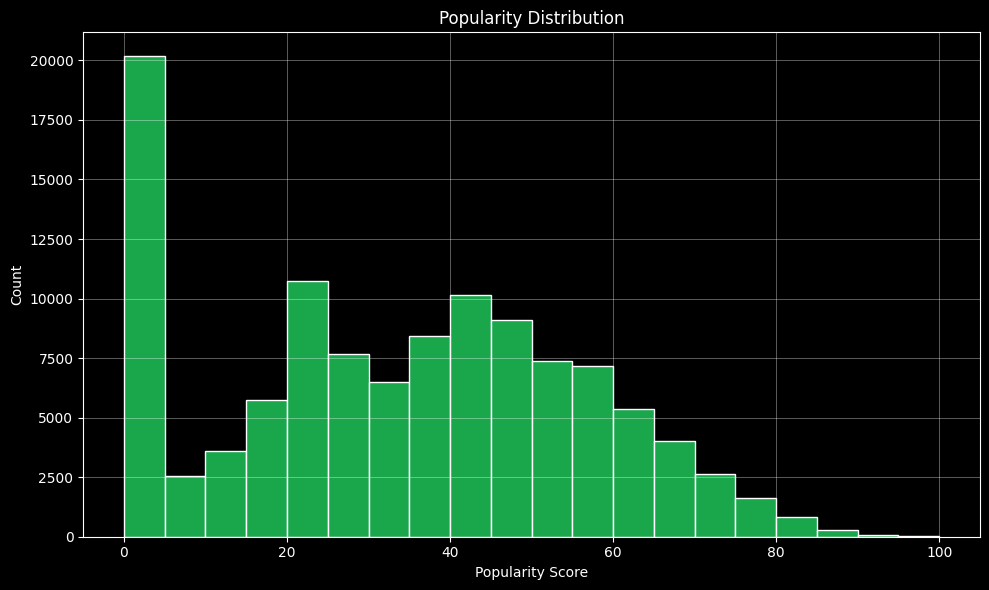

In [11]:
SPOTIFY_GREEN = "#1DB954"

plt.style.use("dark_background")  # Spotify-like dark UI

plt.figure(figsize=(10, 6))
sns.histplot(
    df["popularity"],
    bins=20,
    kde=False,
    color=SPOTIFY_GREEN,
    edgecolor="white",
    alpha=0.9
)

plt.title("Popularity Distribution", color="white")
plt.xlabel("Popularity Score", color="white")
plt.ylabel("Count", color="white")
plt.tick_params(axis="x", colors="white")
plt.tick_params(axis="y", colors="white")

# Soften grid lines on dark background
ax = plt.gca()
ax.grid(False)  # remove default grid
ax.grid(True, color="#ffffff", alpha=0.5, linewidth=0.5)  # custom, less bright grid

plt.tight_layout()
plt.show()

#### 2.6 Virality Rate by Genre

In [12]:
genre_virality = (
    df.groupby('track_genre')['viral']
    .mean()
    .sort_values(ascending=False)
)

top_genres = (
    df['track_genre']
    .value_counts()
    .head(20)
    .index
)

df_top = df[df['track_genre'].isin(top_genres)]

genre_virality = (
    df_top.groupby('track_genre')['viral']
    .mean()
    .sort_values(ascending=False)
    
)